
# Untreated CoCulture Math Modelling

This notebook fits a two-population (sensitive / resistant) competition model to untreated co-culture datasets.

Data root (relative to project root):

- `Processed_Datasets/Untreated CoCulture/20k`
- `Processed_Datasets/Untreated CoCulture/30k`

Parameter priors are taken from the untreated monoculture fits in:

- `Modelling Data Notebooks/Untreated MonoCulture/untreated_monoculture_logistic_parameters.csv`


In [1]:

# 1) Packages

using Pkg

pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations",
    "Optimization", "OptimizationOptimJL",
    "Plots", "Glob"
]

for p in pkgs
    @info "Loading package $(p)"
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch e
        @warn "Package $(p) not found, attempting to add" exception=(e, catch_backtrace())
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end

using CSV, DataFrames, Statistics
using DifferentialEquations
using Optimization, OptimizationOptimJL
using Plots
using Glob

default(linewidth = 2, legend = :right, framestyle = :box)

@assert occursin("DataFrame", string(DataFrame)) "DataFrames not loaded correctly"


[ Info: Loading package CSV
[ Info: Loading package DataFrames
[ Info: Loading package Statistics
[ Info: Loading package DifferentialEquations
[ Info: Loading package Optimization
[ Info: Loading package OptimizationOptimJL
[ Info: Loading package Plots
[ Info: Loading package Glob



## 2) Paths and configuration

Assumes this notebook lives in:

`Modelling Data Notebooks/Untreated CoCulture/`

so that `project_root = dirname(dirname(pwd()))`.


In [2]:
# 2) Paths and configuration

using CSV, DataFrames

# -----------------------------
# Project + directory structure
# -----------------------------

# Project root: one level above 'Modelling Data Notebooks'
project_root = dirname(dirname(pwd()))

raw_coculture_dir = joinpath(project_root, "Datasets", "Untreated CoCulture")
coculture_root    = joinpath(project_root, "Processed_Datasets", "Untreated CoCulture")

# Allow easy extension to other seeding densities later
seeding_levels = ("20k", "30k")
processed_coculture_dirs = [joinpath(coculture_root, s) for s in seeding_levels]

# Untreated monoculture parameter CSV (for priors / reference)
monoculture_param_path = joinpath(
    project_root,
    "Modelling Data Notebooks",
    "Untreated MonoCulture",
    "untreated_monoculture_logistic_parameters.csv",
)

@info "project_root            = $(project_root)"
@info "raw_coculture_dir       = $(raw_coculture_dir)"
@info "coculture_root          = $(coculture_root)"
@info "processed_coculture_dirs = $(processed_coculture_dirs)"
@info "monoculture_param_path  = $(monoculture_param_path)"

# -----------------------------
# Sanity checks on directories
# -----------------------------

@assert isdir(project_root)          "project_root does not exist: $project_root"
@assert isdir(raw_coculture_dir)     "Raw coculture directory missing: $raw_coculture_dir"
@assert isdir(coculture_root)        "Coculture root directory missing: $coculture_root"
@assert all(isdir, processed_coculture_dirs) "One or more processed coculture directories are missing"

# ---------------------------------------------
# Helper: recursively collect all day_averages
# ---------------------------------------------

if !@isdefined collect_day_average_files
    """
    Recursively collect all '*day_averages.csv' files under a set of roots.

    This is robust to cis/non_cis/Averages nesting and future subdirectory changes.
    """
    function collect_day_average_files(roots::Vector{String})
        files = String[]
        for r in roots
            isdir(r) || continue
            for (root, _, filelist) in walkdir(r)
                for f in filelist
                    if endswith(f, "day_averages.csv")
                        push!(files, joinpath(root, f))
                    end
                end
            end
        end
        return files
    end
end

all_day_average_files = collect_day_average_files(processed_coculture_dirs)

@assert !isempty(all_day_average_files) "No coculture day-average files found under $(processed_coculture_dirs)"

println("\nFound $(length(all_day_average_files)) coculture day-average CSVs:")
for f in sort(all_day_average_files)
    println("  - " * f)
end

# ---------------------------------------------
# Load untreated monoculture logistic parameters
# ---------------------------------------------

@assert isfile(monoculture_param_path) "Untreated monoculture parameter CSV missing: $monoculture_param_path"

available_monoculture_params = CSV.read(monoculture_param_path, DataFrame)

println("\nMonoculture reference rows: $(nrow(available_monoculture_params))")
if nrow(available_monoculture_params) > 0
    println("Sample monoculture params:")
    display(first(available_monoculture_params, min(5, nrow(available_monoculture_params))))
end


[ Info: project_root            = c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics
[ Info: raw_coculture_dir       = c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Datasets\Untreated CoCulture
[ Info: coculture_root          = c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture
[ Info: processed_coculture_dirs = ["c:\\Users\\elbak\\Documents\\GitHub\\CancerGrowthDynamics\\Processed_Datasets\\Untreated CoCulture\\20k", "c:\\Users\\elbak\\Documents\\GitHub\\CancerGrowthDynamics\\Processed_Datasets\\Untreated CoCulture\\30k"]
[ Info: monoculture_param_path  = c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv



Found 24 coculture day-average CSVs:
  - c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_25-75A2780cisCoUntreat_4500Thres_day_averages.csv
  - c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_25-75A2780cisCoUntreat_4500Thres_well_day_averages.csv
  - c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_50-50A2780cisCoUntreat_4500Thres_day_averages.csv
  - c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_50-50A2780cisCoUntreat_4500Thres_well_day_averages.csv
  - c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_75-25A2780cisCoUntreat_4000Thres_day_averages.csv
  - c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\2

Row,File,Density,CellLine,r,K,SSR,BIC
,String31,String3,String15,Float64,Float64,Float64,Float64
1,A2780Naive_day_averages.csv,20k,A2780Naive,1.19635,3957.42,5.23373e5,152.684
2,A2780cis_day_averages.csv,20k,A2780cis,0.7173,3914.16,7.9951e5,178.652
3,A2780Naive_day_averages.csv,30k,A2780Naive,1.05209,3878.46,6.08766e5,154.8
4,A2780cis_day_averages.csv,30k,A2780cis,0.700161,3889.65,7.45434e5,177.531



## 3) Data loading (cis + non\_cis Averages)

We load per-condition average trajectories from:

`Processed_Datasets/Untreated CoCulture/{20k,30k}/{cis,non_cis}/Averages/*.csv`

Each cis/non\_cis pair with matching mix label (e.g. `25-75`) and density
is combined into a single `CoCultureDataset`.


Matched 6 cis/non_cis dataset pairs.
Loaded 6 matched cis/non_cis datasets.


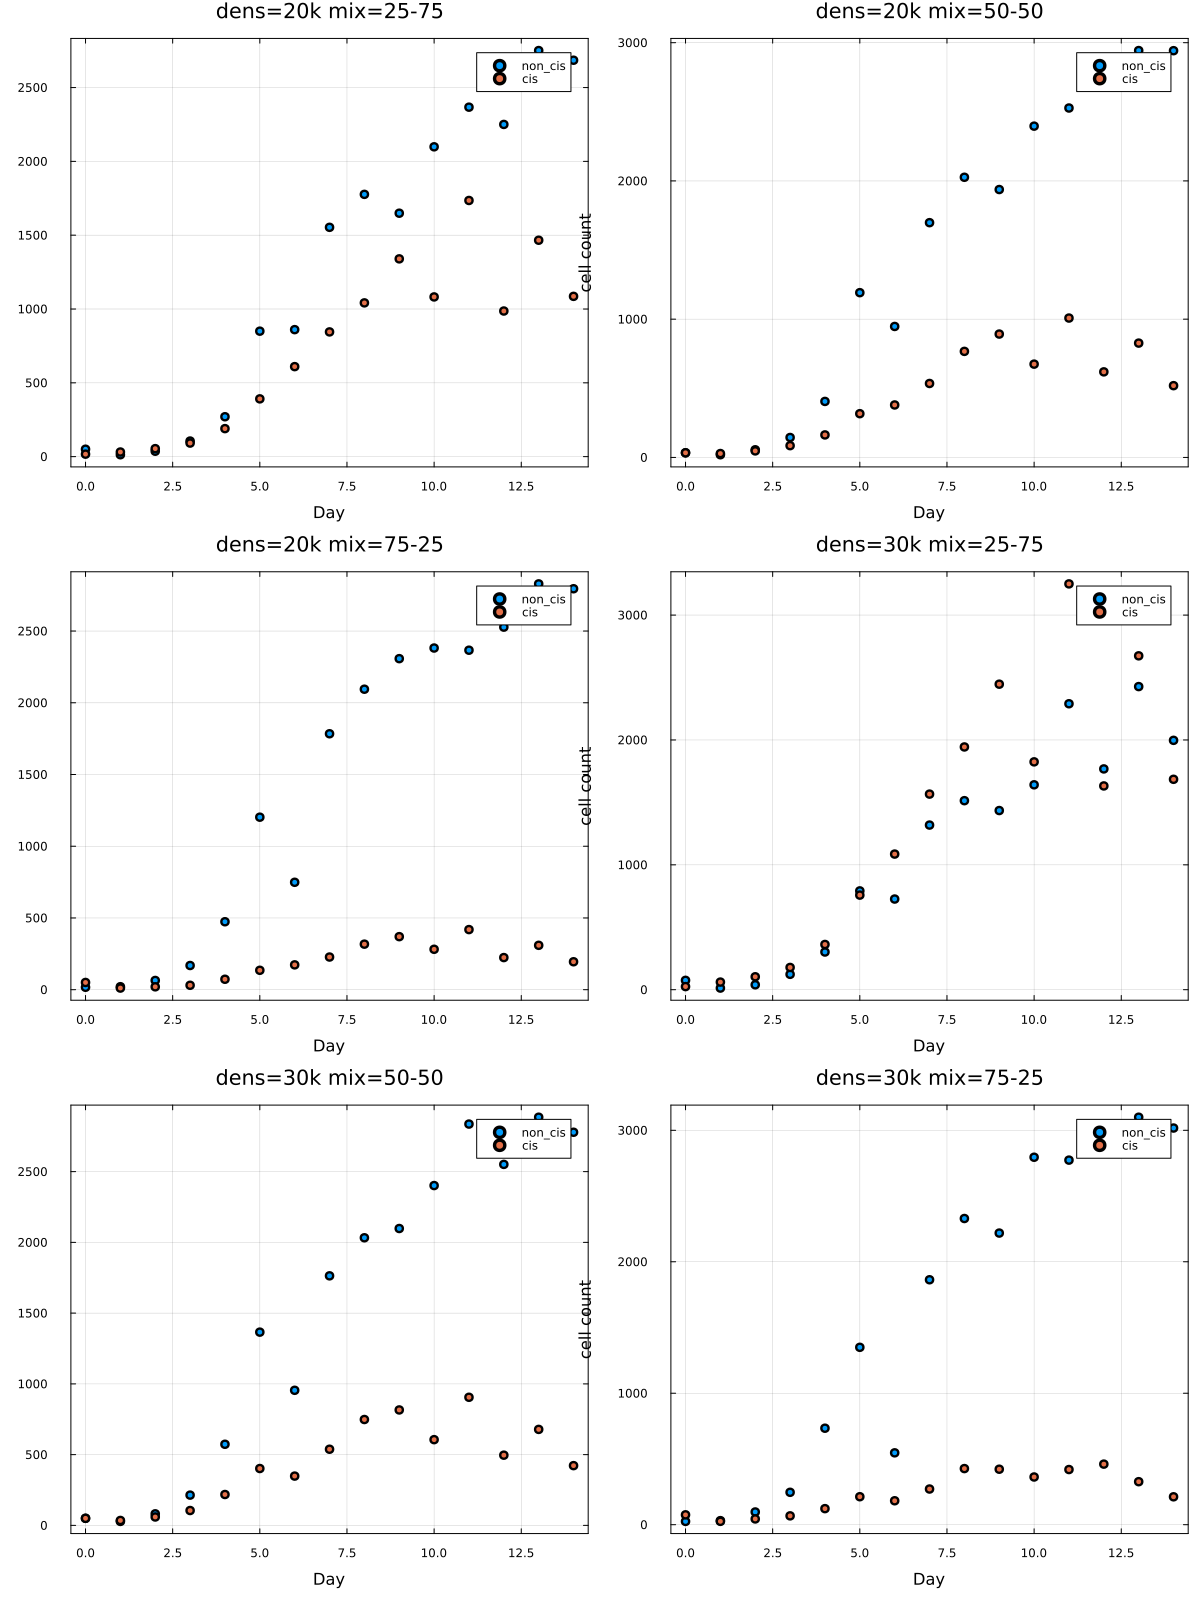

In [3]:
# 3) Data loading utilities + sanity plots

using CSV, DataFrames
using Plots

struct CoCultureDataset
    density::String
    mix_label::String          # e.g. "25-75"
    t::Vector{Float64}
    cis::Vector{Float64}
    non_cis::Vector{Float64}
end

# ---------------------------
# Global options
# ---------------------------

# false -> use plate-level "*_day_averages.csv" (Day, day_mean_cells, n_wells)
# true  -> use well-level  "*_well_day_averages.csv" (Day, mean_cells, ...)
const USE_WELL_LEVEL = false

# Use more specific suffixes so we distinguish day_ vs well_day_
const DAY_SUFFIX       = "_day_averages.csv"
const WELL_DAY_SUFFIX  = "_well_day_averages.csv"

wanted_suffix() = USE_WELL_LEVEL ? WELL_DAY_SUFFIX : DAY_SUFFIX

# ---------------------------
# Helpers to parse metadata
# ---------------------------

"""
Extract (density, compartment) from a full path.

Assumes structure:
    .../Untreated CoCulture/<density>/<compartment>/Averages/...
"""
function parse_density_compartment(path::AbstractString)
    parts = splitpath(path)
    idx = findfirst(==("Untreated CoCulture"), parts)
    idx === nothing && error("Could not find 'Untreated CoCulture' in path: $path")
    length(parts) >= idx + 2 || error("Path too short to extract density/compartment: $path")

    density     = parts[idx + 1]   # "20k", "30k", etc.
    compartment = parts[idx + 2]   # "cis" or "non_cis"
    return density, compartment
end

"""
Extract mix label like "25-75" from filename of the form:
    measure_25-75A2780cisCoUntreat_4500Thres_day_averages.csv
"""
function parse_mix_label(path::AbstractString)
    fname = splitpath(path)[end]
    m = match(r"measure_([0-9]+-[0-9]+)", fname)
    return m === nothing ? "unknown" : m.captures[1]
end

# ---------------------------
# Column detection + loading
# ---------------------------

"""
Given a DataFrame, detect time and count columns based on known schemas.

For your current data:
    plate-level: Day, day_mean_cells, n_wells
    well-level:  Day, Well, mean_cells, n_tiles, channel_count
"""
function detect_time_count_cols(df::DataFrame)
    names_df  = names(df)
    names_str = [lowercase(String(n)) for n in names_df]

    # time column: look for "day" or "time" in a case-insensitive way
    t_idx = findfirst(s -> s in ("day", "time"), names_str)
    t_idx === nothing && error("Could not find a suitable time column in $(names_df)")

    # count column: slightly different preference order depending on level
    if USE_WELL_LEVEL
        target_counts = ("mean_cells", "day_mean_cells", "avg_count")
    else
        target_counts = ("day_mean_cells", "mean_cells", "avg_count")
    end

    c_idx = findfirst(s -> s in target_counts, names_str)
    c_idx === nothing && error("Could not find a suitable count column in $(names_df)")

    tcol = names_df[t_idx]
    ccol = names_df[c_idx]

    return tcol, ccol
end

"""
Load a single compartment CSV and return (t, counts)
"""
function load_single_compartment(file::String)
    df = CSV.read(file, DataFrame)
    tcol, ccol = detect_time_count_cols(df)

    t      = Float64.(df[!, tcol])
    counts = Float64.(df[!, ccol])

    return t, counts
end

# ---------------------------
# Day 0 handling with mix scaling
# ---------------------------

"""
Return the Day 0 TOTAL baseline count given the density label.
Currently:
  20k -> 67
  30k -> 100
"""
function day0_total_baseline(density::String)
    density == "20k" && return 67.0
    density == "30k" && return 100.0
    error("No Day 0 baseline defined for density = $density")
end

"""
Given a mix label like "25-75" and a compartment, return the fraction
of the total baseline to assign to that compartment.

Assumes the first number in mix_label is cis, second is non_cis.
"""
function mix_fraction(mix_label::String, compartment::String)
    mix_label == "unknown" && error("Cannot compute mix fraction for mix_label='unknown'")
    parts = split(mix_label, '-')
    length(parts) == 2 || error("Unexpected mix_label format: $mix_label")

    a = parse(Float64, parts[1])  # cis fraction number
    b = parse(Float64, parts[2])  # non_cis fraction number
    total = a + b

    if compartment == "cis"
        return a / total
    elseif compartment == "non_cis"
        return b / total
    else
        error("Unknown compartment: $compartment")
    end
end

# ---------------------------
# Main loader
# ---------------------------

function load_coculture_datasets()
    @assert @isdefined(all_day_average_files) "all_day_average_files must be defined in the configuration cell"

    suffix = wanted_suffix()

    # Map (density, compartment, mix_label) → file path
    by_key = Dict{Tuple{String,String,String},String}()

    for f in all_day_average_files
        fname = splitpath(f)[end]

        if USE_WELL_LEVEL
            endswith(fname, WELL_DAY_SUFFIX) || continue
        else
            # Only pure plate-level files, not the well-level ones
            endswith(fname, DAY_SUFFIX) || continue
            occursin("_well_", fname) && continue
        end

        density, compartment = parse_density_compartment(f)
        mix = parse_mix_label(f)
        key = (density, compartment, mix)
        by_key[key] = f
    end

    @assert !isempty(by_key) "No files with suffix '$suffix' (and appropriate pattern) found in all_day_average_files"

    densities = sort(unique(k[1] for k in keys(by_key)))
    mixes     = sort(unique(k[3] for k in keys(by_key)))

    datasets = CoCultureDataset[]

    for density in densities, mix in mixes
        cis_key    = (density, "cis",     mix)
        noncis_key = (density, "non_cis", mix)

        # Require both compartments to exist
        haskey(by_key, cis_key)    || continue
        haskey(by_key, noncis_key) || continue

        # Load cis and non_cis time series
        t_cis,    cis    = load_single_compartment(by_key[cis_key])
        t_noncis, noncis = load_single_compartment(by_key[noncis_key])

        @assert length(t_cis) == length(t_noncis) "time length mismatch for density=$(density), mix=$(mix)"
        @assert all(t_cis .== t_noncis)          "time grid mismatch for density=$(density), mix=$(mix)"

        # Day 0 total baseline for this density
        total0 = day0_total_baseline(density)

        # Split according to mix for cis and non_cis
        frac_cis    = mix_fraction(mix, "cis")
        frac_noncis = mix_fraction(mix, "non_cis")

        cis0    = frac_cis    * total0
        noncis0 = frac_noncis * total0

        # Prepend Day 0
        t_full      = vcat(0.0, t_cis)
        cis_full    = vcat(cis0,    cis)
        noncis_full = vcat(noncis0, noncis)

        push!(datasets, CoCultureDataset(density, mix, t_full, cis_full, noncis_full))
    end

    @assert !isempty(datasets) "No matched cis/non_cis dataset pairs found (suffix='$suffix')."

    println("Matched $(length(datasets)) cis/non_cis dataset pairs.")
    return datasets
end

datasets = load_coculture_datasets()
println("Loaded $(length(datasets)) matched cis/non_cis datasets.")
first(datasets)

# ---------------------------
# 3a) Sanity plots
# ---------------------------
# ---------------------------
# 3a) Sanity plots (3x2 grid)
# ---------------------------

function plot_dataset_subplot!(plt, ds::CoCultureDataset)
    plot!(plt,
        ds.t, ds.non_cis,
        seriestype = :scatter,
        markersize = 4,
        label = "non_cis"
    )
    plot!(plt,
        ds.t, ds.cis,
        seriestype = :scatter,
        markersize = 4,
        label = "cis"
    )
    title!(plt, "dens=$(ds.density) mix=$(ds.mix_label)")
end

function plot_all_datasets_grid(datasets::Vector{CoCultureDataset})
    chunk_size = 6
    n = length(datasets)

    for i in 1:chunk_size:n
        idxs = i:min(i+chunk_size-1, n)
        ds_chunk = datasets[idxs]

        # 3 rows × 2 columns
        plt = plot(layout = (3, 2), size = (1200, 1600))

        for (j, ds) in enumerate(ds_chunk)
            subplot = plt[j]
            plot!(
                subplot,
                xlabel = "Day",
                ylabel = "cell count",
                legend = :topright,
            )
            plot_dataset_subplot!(subplot, ds)
        end

        display(plt)
    end
end

plot_all_datasets_grid(datasets)




## 4) Model: untreated S/R competition

We use the Lotka–Volterra competition model with background death:

\[
\frac{dS}{dt} = r_S S \left(1 - \frac{S+R}{K}\right) - d_S S, \qquad
\frac{dR}{dt} = r_R R \left(1 - \frac{S+R}{K}\right) - d_R R.
\]

`S` corresponds to the non-cis (drug-sensitive) population,
`R` to the cis (drug-resistant) population.


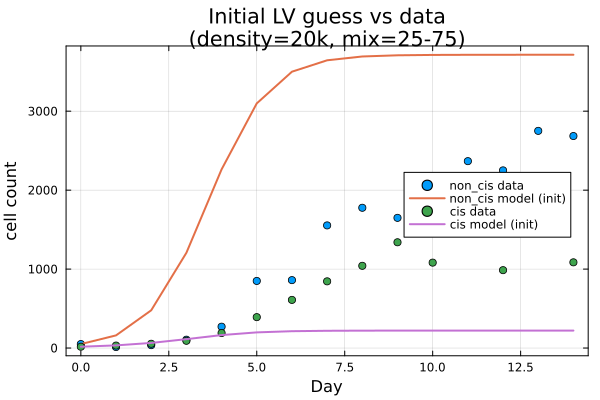

In [5]:
# 4) Model and simulation helpers

using DifferentialEquations
using Plots

# ---------------------------
# LV system (untreated S–R)
# ---------------------------

function lv_untreated!(du, u, p, t)
    S, R = u
    rS, rR, K, dS, dR = p
    N = S + R
    du[1] = rS * S * (1 - N / K) - dS * S
    du[2] = rR * R * (1 - N / K) - dR * R
    return nothing
end

function simulate_lv(ds::CoCultureDataset, p; solver_kwargs...)
    S0 = ds.non_cis[1]   # sensitive
    R0 = ds.cis[1]       # resistant
    u0 = [S0, R0]

    @assert !isempty(ds.t) "Dataset has empty time vector"
    @assert ds.t[1] == 0.0 "Expected ds.t to start at Day 0, got $(ds.t[1])"

    tspan = (first(ds.t), last(ds.t))

    prob = ODEProblem(lv_untreated!, u0, tspan, p)
    sol  = solve(prob, Tsit5(); saveat = ds.t, solver_kwargs...)

    S = Array(sol[1, :])
    R = Array(sol[2, :])
    return (ds.t, S, R)
end

# -----------------------------------------------
# Monoculture-derived priors for LV parameters
# -----------------------------------------------

# Exact CSV column names:
# File, Density, CellLine, r, K, SSR, BIC
const MONO_FILE_COL    = :File
const MONO_DENSITY_COL = :Density
const MONO_CELL_COL    = :CellLine
const MONO_R_COL       = :r
const MONO_K_COL       = :K
# There is NO death-rate column → we set d = 0.0

# Map coculture compartments → monoculture cell lines
const COMPARTMENT_TO_CELL_LINE = Dict(
    :non_cis => "A2780Naive",
    :cis     => "A2780cis",
)

function get_mono_params(cell_line::AbstractString, density::AbstractString)
    @assert @isdefined(available_monoculture_params)

    df = filter(row ->
        row[MONO_CELL_COL] == cell_line &&
        string(row[MONO_DENSITY_COL]) == density,
        available_monoculture_params
    )

    @assert nrow(df) == 1 "Expected one row for $(cell_line), density=$(density); got $(nrow(df))"

    r_val = df[1, MONO_R_COL]
    K_val = df[1, MONO_K_COL]
    d_val = 0.0    # untreated monoculture has no death term

    return (r = r_val, K = K_val, d = d_val)
end

function initial_guess_lv(ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    dS0 = mono_non.d   # = 0.0
    dR0 = mono_cis.d   # = 0.0

    return Float64[rS0, rR0, K0, dS0, dR0]
end

# -----------------------------------------------
# Quick forward simulation test using priors
# -----------------------------------------------

test_ds = datasets[1]
p0_vec = initial_guess_lv(test_ds)
p0 = (p0_vec[1], p0_vec[2], p0_vec[3], p0_vec[4], p0_vec[5])

t_sim, S_sim, R_sim = simulate_lv(test_ds, p0)

plt = plot(
    xlabel = "Day",
    ylabel = "cell count",
    title  = "Initial LV guess vs data\n(density=$(test_ds.density), mix=$(test_ds.mix_label))",
)

scatter!(plt, test_ds.t, test_ds.non_cis, label = "non_cis data")
plot!(plt, t_sim, S_sim, label = "non_cis model (init)")
scatter!(plt, test_ds.t, test_ds.cis,     label = "cis data")
plot!(plt, t_sim, R_sim, label = "cis model (init)")

display(plt)



## 5) Fitting the model (per dataset)

We fit \(r_S, r_R, K, d_S, d_R\) by minimizing the joint SSE across both
cis and non-cis trajectories.


In [ ]:

# 5) Fitting routines

function sse_lv(p_vec, ds::CoCultureDataset)
    p = (p_vec[1], p_vec[2], p_vec[3], p_vec[4], p_vec[5])
    t, S, R = simulate_lv(ds, p; abstol = 1e-8, reltol = 1e-6)
    err_S = S .- ds.non_cis
    err_R = R .- ds.cis
    return sum(err_S .^ 2 .+ err_R .^ 2)
end

const LV_LOWER = [0.0, 0.0, 1e3, 0.0, 0.0]
const LV_UPPER = [2.0, 2.0, 1e8, 1.0, 1.0]

function fit_lv(ds::CoCultureDataset)
    p0 = initial_guess_lv(ds)
    loss(p) = sse_lv(p, ds)

    optprob = Optimization.OptimizationProblem(loss, p0)
    res = Optimization.solve(optprob, Optim.BFGS(); allow_f_increases = false)

    p̂ = res.u
    sse = res.minimum
    n   = 2 * length(ds.t)
    k   = length(p̂)

    σ2  = sse / n
    aic = n * log(σ2) + 2k
    bic = n * log(σ2) + k * log(n)

    return (
        density   = ds.density,
        mix       = ds.mix_label,
        model     = "LV_competition",
        rS        = p̂[1],
        rR        = p̂[2],
        K         = p̂[3],
        dS        = p̂[4],
        dR        = p̂[5],
        sse       = sse,
        aic       = aic,
        bic       = bic,
        converged = res.retcode
    )
end

# Example fit and diagnostic plot for the first dataset
single_fit = fit_lv(test_ds)
println(single_fit)

t_fit, S_fit, R_fit = simulate_lv(test_ds, (single_fit.rS, single_fit.rR, single_fit.K, single_fit.dS, single_fit.dR))

plt1 = plot(test_ds.t, test_ds.non_cis, seriestype = :scatter, label = "non_cis data",
            xlabel = "time", ylabel = "cell count", title = "density=$(test_ds.density), mix=$(test_ds.mix_label)")
plot!(plt1, t_fit, S_fit, label = "non_cis fit")

plt2 = plot(test_ds.t, test_ds.cis, seriestype = :scatter, label = "cis data",
            xlabel = "time", ylabel = "cell count")
plot!(plt2, t_fit, R_fit, label = "cis fit")

plot(plt1, plt2, layout = (1, 2), size = (900, 350))


In [ ]:

# 6) Fit all datasets and export summary

results = NamedTuple[]
for ds in datasets
    println("Fitting LV model: density=$(ds.density), mix=$(ds.mix_label)")
    push!(results, fit_lv(ds))
end

fit_df = DataFrame(results)
println("\nFit summary (first 10 rows):")
display(first(fit_df, min(10, nrow(fit_df))))

# Export for downstream analysis
output_file = joinpath(pwd(), "untreated_coculture_LV_parameters.csv")
CSV.write(output_file, fit_df)
println("\nExported parameter table to: " * output_file)
@assert isfile(output_file) "Export failed"

# Basic BIC analysis
sort!(fit_df, [:bic])
println("\nBest fits by BIC:")
display(fit_df)

histogram(fit_df.bic, bins = 10, xlabel = "BIC", ylabel = "count", title = "BIC across coculture datasets")
